## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('European_Bank.csv')

In [3]:
sns.set_theme(style="whitegrid", palette="muted")

## Loading Dataset

In [4]:
df = pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Validation

In [5]:
df.shape

(10000, 14)

In [6]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

print("Binary Variable Validation:")
for col in binary_cols:
    unique_vals = df[col].unique()
    if set(unique_vals).issubset({0, 1}):
        print(f"'{col}' is consistently binary: {unique_vals}")
    else:
        print(f"WARNING: '{col}' contains non-binary values: {unique_vals}")


Binary Variable Validation:
'HasCrCard' is consistently binary: [1 0]
'IsActiveMember' is consistently binary: [1 0]
'Exited' is consistently binary: [1 0]


In [8]:
churn_rate = df['Exited'].mean() * 100
print(f"\nBaseline Churn Rate: {churn_rate:.2f}%")


Baseline Churn Rate: 20.37%


## Engagement Profiles

In [9]:
high_balance_threshold = df[df['Balance'] > 0]['Balance'].median() 

def assign_profile(row):
    active = row['IsActiveMember'] == 1
    products = row['NumOfProducts']
    high_bal = row['Balance'] > high_balance_threshold

    if active and products > 1:
        return 'Active Engaged'
    elif not active and high_bal:
        return 'Inactive High-Balance'
    elif active and products == 1:
        return 'Active Low-Product'
    elif not active and products == 1:
        return 'Inactive Disengaged'
    else:
        return 'Other Inactive' 

df['Engagement_Profile'] = df.apply(assign_profile, axis=1)

print("Engagement Profile Distribution (%):")
print((df['Engagement_Profile'].value_counts(normalize=True) * 100).round(2))

Engagement Profile Distribution (%):
Engagement_Profile
Active Engaged           25.88
Active Low-Product       25.63
Other Inactive           18.13
Inactive High-Balance    15.69
Inactive Disengaged      14.67
Name: proportion, dtype: float64


## Visualize Churn by Profile
### • Evaluate the relationship between engagement and churn

C:\Users\TUF GAMING\AppData\Local\Temp\ipykernel_25632\2180251076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile_churn.index, y=profile_churn.values, palette='Reds_r')


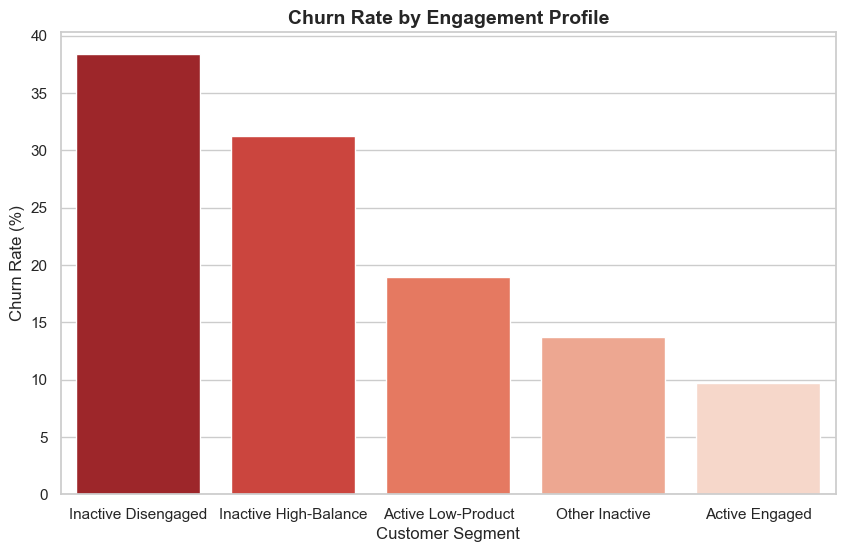

In [10]:
profile_churn = df.groupby('Engagement_Profile')['Exited'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=profile_churn.index, y=profile_churn.values, palette='Reds_r')
plt.title('Churn Rate by Engagement Profile', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Segment')
plt.show()

## Calculate Churn by Product Count
### • Measure retention impact of product count and product mix
### • Improve product bundling decisions

In [11]:
prod_churn = df.groupby('NumOfProducts')['Exited'].agg(['count', 'mean'])
prod_churn['mean'] = (prod_churn['mean'] * 100).round(2)
prod_churn.columns = ['Customer_Count', 'Churn_Rate_%']

print("Churn Rate by Product Count:")
print(prod_churn)

df['Is_MultiProduct'] = df['NumOfProducts'] > 1
multi_churn = df.groupby('Is_MultiProduct')['Exited'].mean() * 100

print(f"\nSingle-Product Churn Rate: {multi_churn[False]:.2f}%")
print(f"Multi-Product (2+) Churn Rate: {multi_churn[True]:.2f}%")


Churn Rate by Product Count:
               Customer_Count  Churn_Rate_%
NumOfProducts                              
1                        5084         27.71
2                        4590          7.58
3                         266         82.71
4                          60        100.00

Single-Product Churn Rate: 27.71%
Multi-Product (2+) Churn Rate: 12.77%


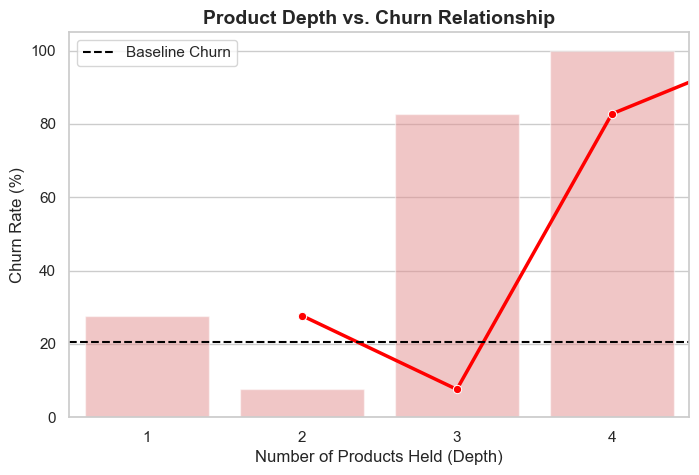

Insight: Product depth improves retention up to 2 products. Depth beyond 2 drastically increases churn.


In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=prod_churn.index, y=prod_churn['Churn_Rate_%'], marker='o', color='red', linewidth=2.5)
sns.barplot(x=prod_churn.index, y=prod_churn['Churn_Rate_%'], color='lightcoral', alpha=0.5)

plt.title('Product Depth vs. Churn Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products Held (Depth)')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=churn_rate, color='black', linestyle='--', label='Baseline Churn')
plt.legend()
plt.show()

print("Insight: Product depth improves retention up to 2 products. Depth beyond 2 drastically increases churn.")


## Detect At-Risk Premium Customers
### • Identify disengaged yet high-value customers

In [13]:
df['Balance_to_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 0.01)

top_25_balance = df['Balance'].quantile(0.75)

df['Premium_At_Risk'] = ((df['Balance'] > top_25_balance) & (df['IsActiveMember'] == 0)).astype(int)

premium_risk_count = df['Premium_At_Risk'].sum()
premium_risk_churn = df[df['Premium_At_Risk'] == 1]['Exited'].mean() * 100

print(f"Detected {premium_risk_count} 'At-Risk Premium Customers' (High Balance + Inactive).")
print(f"Churn rate for this high-value segment: {premium_risk_churn:.2f}%")


Detected 1247 'At-Risk Premium Customers' (High Balance + Inactive).
Churn rate for this high-value segment: 30.47%


In [14]:
print("--- Balance vs Activity Cross-Analysis ---")
activity_bal = df.groupby('IsActiveMember')['Balance'].mean()
print(f"Average Balance - Inactive: ${activity_bal[0]:,.2f}")
print(f"Average Balance - Active:   ${activity_bal[1]:,.2f}")
print("Insight: Inactive members actually hold slightly higher average balances than active members!\n")

print("--- Salary-Balance Mismatch ---")
df['Mismatch_Flag'] = (df['Balance_to_Salary_Ratio'] > 2).astype(int)
mismatch_count = df['Mismatch_Flag'].sum()
mismatch_churn = df[df['Mismatch_Flag'] == 1]['Exited'].mean() * 100

print(f"Detected {mismatch_count} customers with a high Balance-to-Salary mismatch (Savings > 2x Annual Salary).")
print(f"Churn rate for mismatched customers: {mismatch_churn:.2f}%")


--- Balance vs Activity Cross-Analysis ---
Average Balance - Inactive: $77,134.38
Average Balance - Active:   $75,875.42
Insight: Inactive members actually hold slightly higher average balances than active members!

--- Salary-Balance Mismatch ---
Detected 1884 customers with a high Balance-to-Salary mismatch (Savings > 2x Annual Salary).
Churn rate for mismatched customers: 24.47%


## Rank Profiles by Churn Stability
### • Evaluate the relationship between engagement and churn
### • Support engagement-driven retention strategies

In [15]:
tier_churn = df.groupby('Engagement_Profile')['Exited'].agg(['count', 'mean'])
tier_churn['mean'] = (tier_churn['mean'] * 100).round(2)

tier_churn = tier_churn.sort_values(by='mean')
tier_churn.columns = ['Customer_Count', 'Churn_Rate_%']

print("Churn Rate by Engagement Profile (Ordered by Retention Strength):")
print(tier_churn)

sticky_profiles = tier_churn[tier_churn['Churn_Rate_%'] < 10.0]
print(f"\nHighly Loyal 'Sticky' Profiles:")
print(list(sticky_profiles.index))

Churn Rate by Engagement Profile (Ordered by Retention Strength):
                       Customer_Count  Churn_Rate_%
Engagement_Profile                                 
Active Engaged                   2588          9.66
Other Inactive                   1813         13.73
Active Low-Product               2563         18.92
Inactive High-Balance            1569         31.23
Inactive Disengaged              1467         38.38

Highly Loyal 'Sticky' Profiles:
['Active Engaged']


## KPIs Implementation

In [16]:
# KPI 1: Engagement Retention Ratio
active_churn = df[df['IsActiveMember'] == 1]['Exited'].mean()
inactive_churn = df[df['IsActiveMember'] == 0]['Exited'].mean()
engagement_ratio = inactive_churn / active_churn

# KPI 2: Product Depth Index
prod_depth_retained = df[df['Exited'] == 0]['NumOfProducts'].mean()
prod_depth_churned = df[df['Exited'] == 1]['NumOfProducts'].mean()

# KPI 3: High-Balance Disengagement Rate
q3_balance = df[df['Balance'] > 0]['Balance'].quantile(0.75)
hb_churn_rate = df[df['Balance'] >= q3_balance]['Exited'].mean() * 100

# KPI 4: Credit Card Stickiness Score
card_churn = df[df['HasCrCard'] == 1]['Exited'].mean() * 100
no_card_churn = df[df['HasCrCard'] == 0]['Exited'].mean() * 100
stickiness = no_card_churn - card_churn

# KPI 5: Relationship Strength Index (RSI)
df['RSI'] = (df['IsActiveMember'] * 0.5) + ((df['NumOfProducts']/4) * 0.5)
rsi_retained = df[df['Exited'] == 0]['RSI'].mean()
rsi_churned = df[df['Exited'] == 1]['RSI'].mean()

print("Custom Business KPIs:")
print(f"1. Engagement Retention Ratio:      {engagement_ratio:.2f}x (Inactive churns {engagement_ratio:.1f}x more)")
print(f"2. Product Depth Index:             Retained hold {prod_depth_retained:.2f} products vs Churned {prod_depth_churned:.2f}")
print(f"3. High-Balance Disengagement Rate: {hb_churn_rate:.2f}% churn among top-tier balances")
print(f"4. Credit Card Stickiness Score:    {stickiness:.2f} percentage points better retention with a card")
print(f"5. Relationship Strength Index:     Retained score {rsi_retained:.3f} vs Churned {rsi_churned:.3f} (0 to 1 scale)")


Custom Business KPIs:
1. Engagement Retention Ratio:      1.88x (Inactive churns 1.9x more)
2. Product Depth Index:             Retained hold 1.54 products vs Churned 1.48
3. High-Balance Disengagement Rate: 22.99% churn among top-tier balances
4. Credit Card Stickiness Score:    0.63 percentage points better retention with a card
5. Relationship Strength Index:     Retained score 0.470 vs Churned 0.365 (0 to 1 scale)


## Final Insights

In [17]:
print("Final Insights & Recommendations")

print("INSIGHT 1: The 'More is Better' Myth is False")
print("Data proves that holding 3 or 4 products exponentially increases churn (82% - 100%).")
print("-> RECOMMENDATION: Halt aggressive cross-selling past 2 products. Audit the customer experience / fee structure for users with 3+ products.\n")

print("INSIGHT 2: The Premium At-Risk Segment")
print(f"There are {df['Premium_At_Risk'].sum()} high-balance customers who are completely inactive, churning at over 30%.")
print("-> RECOMMENDATION: Deploy relationship managers immediately to this specific segment. A high balance does NOT guarantee loyalty without activity.\n")

print("INSIGHT 3: Engagement is the Ultimate Moat")
print(f"Inactive customers are {engagement_ratio:.1f}x more likely to churn than active ones.")
print("-> RECOMMENDATION: Shift marketing budget from 'new customer acquisition' to 'existing customer activation' campaigns.\n")

print("INSIGHT 4: The 'Sticky' Persona")
print("The most loyal segment is 'Active Engaged' (Active members with 2 products), with a churn rate safely below 10%.")
print("-> RECOMMENDATION: Make this the 'North Star' persona. The primary goal of onboarding should be getting a user active and holding exactly 2 products.")


Final Insights & Recommendations
INSIGHT 1: The 'More is Better' Myth is False
Data proves that holding 3 or 4 products exponentially increases churn (82% - 100%).
-> RECOMMENDATION: Halt aggressive cross-selling past 2 products. Audit the customer experience / fee structure for users with 3+ products.

INSIGHT 2: The Premium At-Risk Segment
There are 1247 high-balance customers who are completely inactive, churning at over 30%.
-> RECOMMENDATION: Deploy relationship managers immediately to this specific segment. A high balance does NOT guarantee loyalty without activity.

INSIGHT 3: Engagement is the Ultimate Moat
Inactive customers are 1.9x more likely to churn than active ones.
-> RECOMMENDATION: Shift marketing budget from 'new customer acquisition' to 'existing customer activation' campaigns.

INSIGHT 4: The 'Sticky' Persona
The most loyal segment is 'Active Engaged' (Active members with 2 products), with a churn rate safely below 10%.
-> RECOMMENDATION: Make this the 'North Star'